# Diabetes classification — Pima Indians Diabetes Dataset

Goal: predict `Outcome` (1 = diabetes, 0 = no diabetes) from 8 clinical measurements.

Workflow:
1. Load and explore the data
2. Treat physiologically impossible zeros as missing values
3. Stratified train/test split
4. Compare several classifiers with cross-validation
5. Tune the best model and choose a decision threshold
6. Evaluate on the held-out test set
7. Save the final model

## Imports

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, accuracy_score, f1_score,
                             precision_recall_curve, recall_score, precision_score)
from sklearn.inspection import permutation_importance

randomState = 42
sns.set_theme(style="whitegrid")

## Load and examine data

In [61]:
df = pd.read_csv("data/diabetes.csv")
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### missing values
A value of 0 is impossible for Glucose, BloodPressure, SkinThickness, Insulin, and BMI, so they are really missing values.

In [62]:
zeroAsMissing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
(df[zeroAsMissing] == 0).sum().rename("zero count")

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Name: zero count, dtype: int64

### Visualize

Outcome
0    0.651042
1    0.348958
Name: share, dtype: float64


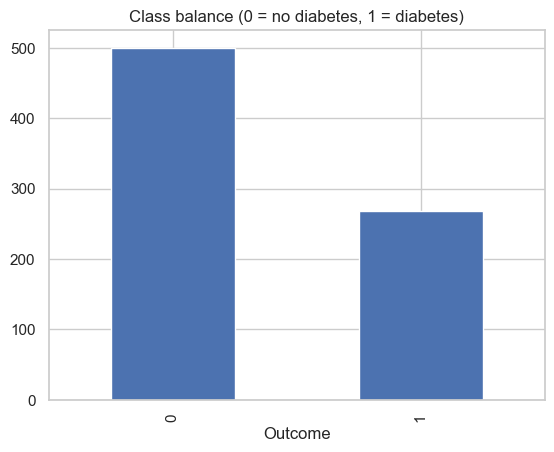

In [63]:
print(df["Outcome"].value_counts(normalize=True).rename("share"))
df["Outcome"].value_counts().plot(kind="bar", title="Class balance (0 = no diabetes, 1 = diabetes)");

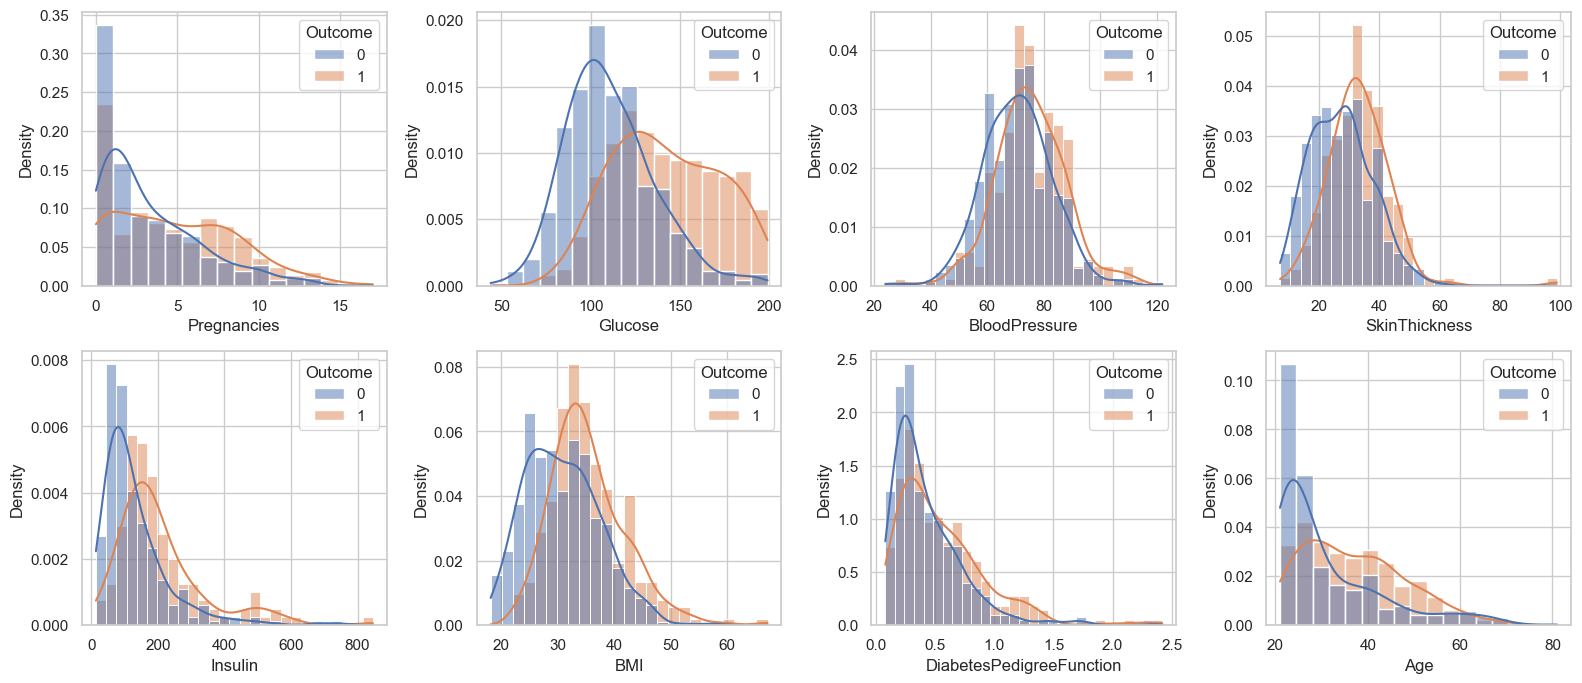

In [64]:
dfPlot = df.copy()
dfPlot[zeroAsMissing] = dfPlot[zeroAsMissing].replace(0, np.nan)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, df.columns[:-1]):
    sns.histplot(data=dfPlot, x=col, hue="Outcome", kde=True, ax=ax, stat="density", common_norm=False)
plt.tight_layout()

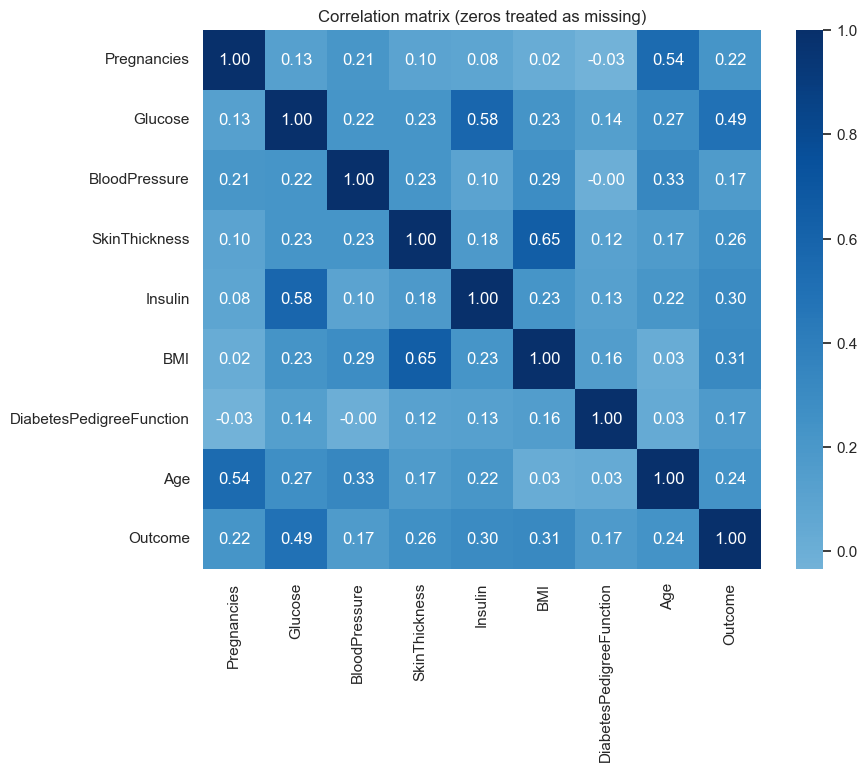

In [65]:
plt.figure(figsize=(9, 7))
sns.heatmap(dfPlot.corr(), annot=True, fmt=".2f", cmap="Blues", center=0)
plt.title("Correlation matrix (zeros treated as missing)");

## Train/test split
Stratify to keep the same ratio for train and test.

In [ ]:
droppedCols = ["Insulin"]
x = df.drop(columns=["Outcome"] + droppedCols)
y = df["Outcome"]

xTrain, xTest, yTrain, yTest = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=randomState)
print(xTrain.shape, xTest.shape)

(614, 7) (154, 7)


## Preprocessing pipeline
- Drop Insulin (too many missing values and weak connection to be useful).
- In the remaining affected columns (Glucose, BloodPressure, SkinThickness, BMI), treat 0 as missing value and switch with the training set median.
- Standardize features, needed for LogReg, KNN, and SVM (makes no difference for trees).

In [ ]:
imputeCols = [c for c in zeroAsMissing if c not in droppedCols]

preprocess = Pipeline([
    ("impute", ColumnTransformer(
        [("zero_as_missing", SimpleImputer(missing_values=0, strategy="median"), imputeCols)],
        remainder="passthrough")),
    ("scale", StandardScaler()),
])

def makePipeline(model):
    """Wrap a classifier with the shared preprocessing so they are fitted together."""
    return Pipeline([("prep", preprocess), ("model", model)])

## Model selection and hyperparameter tuning
Five models are tuned with a grid search: every combination of hyperparameters in the grid is evaluated with stratified 5-fold cross-validation on the training set, optimising ROC AUC. The model with the highest cross-validated ROC AUC is kept.

In [68]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "SVM (RBF)": SVC(probability=True, class_weight="balanced", random_state=randomState),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=randomState),
    "Gradient Boosting": GradientBoostingClassifier(random_state=randomState),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=randomState)

searchSpaces = {
    "Logistic Regression": (models["Logistic Regression"], {"model__C": [0.01, 0.1, 1, 10]}),
    "SVM (RBF)": (models["SVM (RBF)"], {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]}),
    "Random Forest": (models["Random Forest"], {"model__max_depth": [None, 5, 8],
                                               "model__min_samples_leaf": [1, 3, 5],
                                               "model__max_features": ["sqrt", 0.5]}),
    "KNN": (models["KNN"], {"model__n_neighbors": [5, 11, 15, 21, 31],
                            "model__weights": ["uniform", "distance"]}),
    "Gradient Boosting": (models["Gradient Boosting"], {"model__n_estimators": [100, 200],
                                                       "model__learning_rate": [0.05, 0.1],
                                                       "model__max_depth": [2, 3]}),
}

searches = {}
for name, (model, grid) in searchSpaces.items():
    gs = GridSearchCV(makePipeline(model), grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(xTrain, yTrain)
    searches[name] = gs
    print(f"{name:20s} best CV ROC AUC = {gs.best_score_:.3f}  params = {gs.best_params_}")

bestName = max(searches, key=lambda n: searches[n].best_score_)
bestModel = searches[bestName].best_estimator_
print(f"\nSelected model: {bestName}")

Logistic Regression  best CV ROC AUC = 0.846  params = {'model__C': 10}
SVM (RBF)            best CV ROC AUC = 0.848  params = {'model__C': 10, 'model__gamma': 0.01}
Random Forest        best CV ROC AUC = 0.836  params = {'model__max_depth': 5, 'model__max_features': 0.5, 'model__min_samples_leaf': 5}
KNN                  best CV ROC AUC = 0.835  params = {'model__n_neighbors': 15, 'model__weights': 'distance'}
Gradient Boosting    best CV ROC AUC = 0.828  params = {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}

Selected model: SVM (RBF)


## Choose the decision threshold
By default a patient is classified as diabetic when the predicted probability is ≥ 0.5. For screening, missing a diabetic patient (false negative) is worse than a false alarm, so we lower the threshold until recall reaches a target.

The threshold is chosen from out-of-fold cross-validation predictions on the **training set**, so the test set stays untouched until the final evaluation.

Chosen threshold: 0.264
CV recall    at 0.5: 0.593   at 0.264: 0.850
CV precision at 0.5: 0.709   at 0.264: 0.572


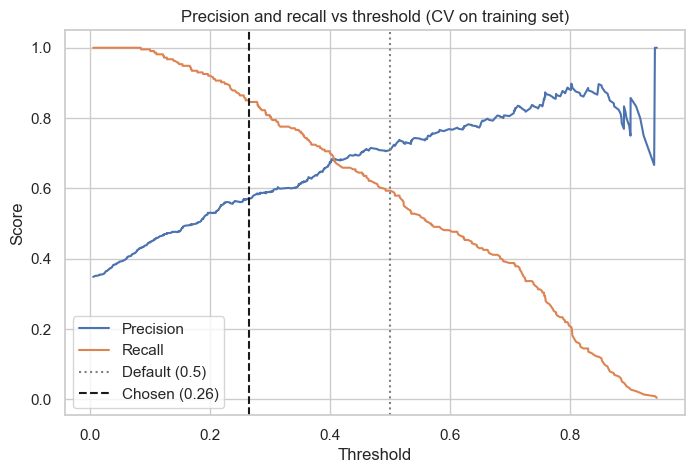

In [69]:
targetRecall = 0.85

cvProb = cross_val_predict(bestModel, xTrain, yTrain, cv=cv, method="predict_proba")[:, 1]

precision, recall, thresholds = precision_recall_curve(yTrain, cvProb)
precision, recall = precision[:-1], recall[:-1]

threshold = thresholds[recall >= targetRecall].max()
cvPred = (cvProb >= threshold).astype(int)
print(f"Chosen threshold: {threshold:.3f}")
print(f"CV recall    at 0.5: {recall_score(yTrain, cvProb >= 0.5):.3f}   at {threshold:.3f}: {recall_score(yTrain, cvPred):.3f}")
print(f"CV precision at 0.5: {precision_score(yTrain, cvProb >= 0.5):.3f}   at {threshold:.3f}: {precision_score(yTrain, cvPred):.3f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision, label="Precision")
plt.plot(thresholds, recall, label="Recall")
plt.axvline(0.5, color="grey", ls=":", label="Default (0.5)")
plt.axvline(threshold, color="k", ls="--", label=f"Chosen ({threshold:.2f})")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend()
plt.title("Precision and recall vs threshold (CV on training set)");

## Evaluate on the test set

In [70]:
yProb = bestModel.predict_proba(xTest)[:, 1]
yPred = (yProb >= threshold).astype(int)

print(f"Final test metrics ({bestName}, threshold {threshold:.3f})")
print(f"AUROC       : {roc_auc_score(yTest, yProb):.3f}")
print(f"Sensitivity : {recall_score(yTest, yPred):.3f}")
print(f"Specificity : {recall_score(yTest, yPred, pos_label=0):.3f}")
print(f"Precision   : {precision_score(yTest, yPred):.3f}")
print(f"F1-score    : {f1_score(yTest, yPred):.3f}")

Final test metrics (SVM (RBF), threshold 0.264)
AUROC       : 0.819
Sensitivity : 0.852
Specificity : 0.650
Precision   : 0.568
F1-score    : 0.681


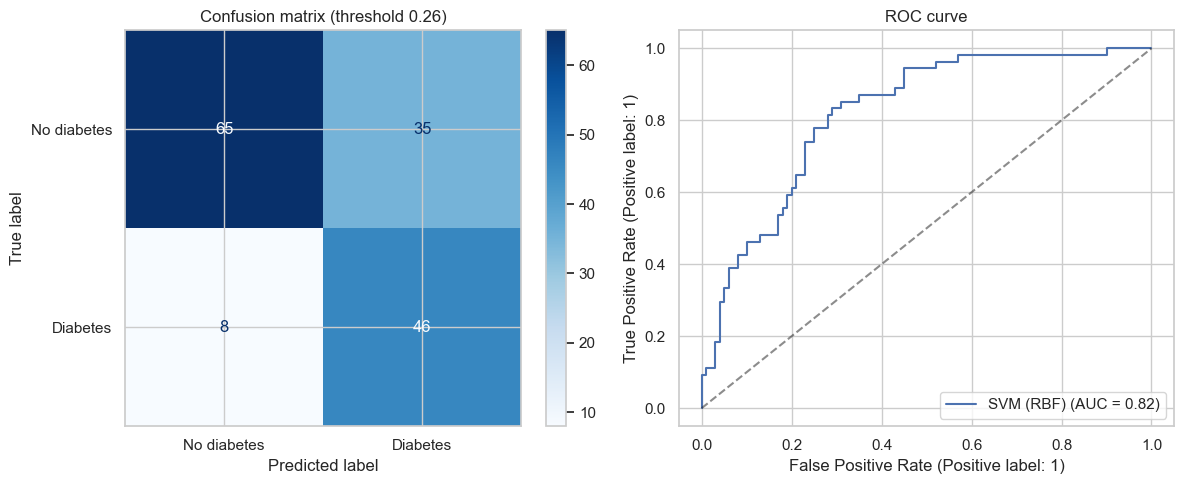

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(yTest, yPred, display_labels=["No diabetes", "Diabetes"],
                                        cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion matrix (threshold {threshold:.2f})")
RocCurveDisplay.from_predictions(yTest, yProb, ax=axes[1], name=bestName)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title("ROC curve")
plt.tight_layout()

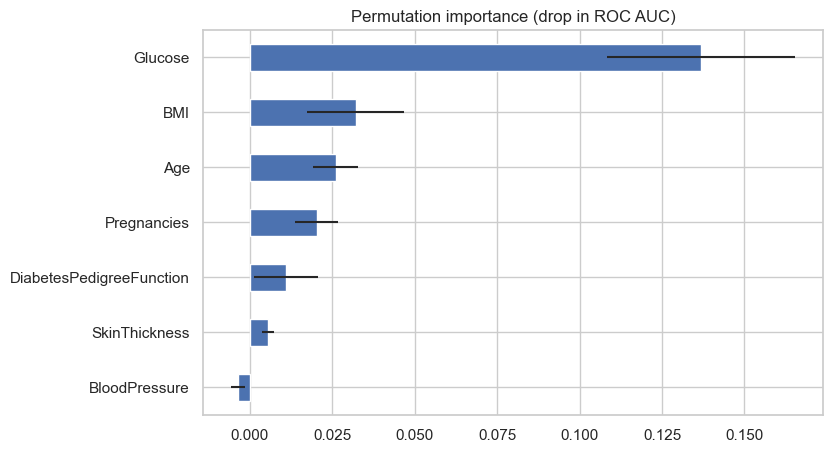

In [72]:
perm = permutation_importance(bestModel, xTest, yTest, scoring="roc_auc",
                              n_repeats=30, random_state=randomState)
imp = pd.Series(perm.importances_mean, index=x.columns).sort_values()
imp.plot(kind="barh", xerr=perm.importances_std[imp.index.map(list(x.columns).index)],
         title="Permutation importance (drop in ROC AUC)", figsize=(8, 5));

## Save the model

In [73]:
joblib.dump({"model": bestModel, "threshold": threshold}, "diabetes_model.joblib");